## 😊 Emotion Detection from Text using NLP & Machine Learning

Welcome! In this notebook, we'll build an end-to-end **Emotion Detection System** that predicts the emotion behind a piece of text using traditional NLP techniques and Machine Learning.

### 🎯 Objectives
- Load and explore the dataset
- Perform Exploratory Data Analysis (EDA)
- Clean and preprocess text
- Convert text into numerical features using TF-IDF
- Train and compare multiple ML models
- Evaluate model performance
- Save the best model for deployment in a Streamlit web application

In [99]:
import contractions
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [100]:
df = pd.read_csv(
    "../data/train.txt",
    sep=";",
    names=["text", "emotion"]
)

df.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [101]:
print(f"📊 Dataset Shape : {df.shape}")
print(f"📝 Number of Samples : {df.shape[0]}")
print(f"📌 Number of Features : {df.shape[1]}")
print(f"📂 Dataset Information : {df.info()}")
print(f"🔍 Missing Values : {df.isnull().sum()}")
print(f"📊 Emotion Distribution : {df['emotion'].value_counts()}")

📊 Dataset Shape : (16000, 2)
📝 Number of Samples : 16000
📌 Number of Features : 2
<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   text     16000 non-null  str  
 1   emotion  16000 non-null  str  
dtypes: str(2)
memory usage: 1.8 MB
📂 Dataset Information : None
🔍 Missing Values : text       0
emotion    0
dtype: int64
📊 Emotion Distribution : emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


In [102]:
not_happy = df[
    df["text"].str.contains(r"\bnot happy\b", case=False, na=False)
]

print("Number of 'not happy' examples:", len(not_happy))
display(not_happy)

Number of 'not happy' examples: 2


,text,emotion
7421,im feeling surprisingly blank about the whole ...,sadness
11464,i feel content if not happy,joy


In [103]:
not_examples = df[df["text"].str.contains(r"\bnot\b", case=False, na=False)]

print("Sentences containing 'not':", len(not_examples))
display(not_examples.head(20))

Sentences containing 'not': 1670


,text,emotion
15,i do not feel reassured anxiety is on each side,joy
25,i still love my so and wish the best for him i...,sadness
35,i am not sure what would make me feel content ...,joy
38,i feel a bit rude writing to an elderly gentle...,anger
44,i was feeling so discouraged we are already ro...,sadness
75,im tired of the book and ready to have it out ...,sadness
89,i will be able to lay on my bed in the dark an...,fear
108,finding out that i am not ill not seriously,joy
110,i feel it rarely advances any worthwhile cause...,joy
114,im not feeling homesick yet so im feeling alri...,sadness


In [104]:
dont_examples = df[df["text"].str.contains("don't", case=False, na=False)]

print("Sentences containing \"don't\":", len(dont_examples))
display(dont_examples.head(20))

Sentences containing "don't": 0


,text,emotion


In [105]:
never_examples = df[df["text"].str.contains(r"\bnever\b", case=False, na=False)]

print("Sentences containing 'never':", len(never_examples))
display(never_examples.head(20))

Sentences containing 'never': 248


,text,emotion
33,i climbed the hill feeling frustrated that id ...,anger
65,i feel selfish as i read back to my former pos...,anger
124,i am very excited to finally meet that compani...,love
135,i suppose he feels badly because he was a bit ...,fear
356,i took away all the disappointed feeling all t...,love
385,i just busy myself with other stuffs but never...,sadness
433,im really like she said only you can understan...,sadness
438,i feel like normally i would be angry because ...,anger
537,ive been studying really hard for it and disco...,sadness
613,i know that i will never see this place again ...,joy


In [106]:
happy_examples = df[df["text"].str.contains(r"\bhappy\b", case=False, na=False)]

print("Sentences containing 'happy':", len(happy_examples))
display(happy_examples.head(20))

Sentences containing 'happy': 234


,text,emotion
84,i feel very happy and excited since i learned ...,joy
131,i feel energetic and bouncy i m more than happ...,joy
202,i feel the reason were apart of each others li...,joy
388,im pretty happy but a little on the nauseated ...,joy
428,im feeling happy and well,joy
451,i didnt feel that welcomed when i first entere...,joy
552,i checked on you was a long time ago i can say...,joy
617,i know shes right because i feel more energeti...,joy
653,i will actually feel comfortable speaking to o...,joy
724,i feel numb right now i thought i was feeling ...,sadness


C:\Users\nsree\AppData\Local\Temp\ipykernel_28412\1593507618.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


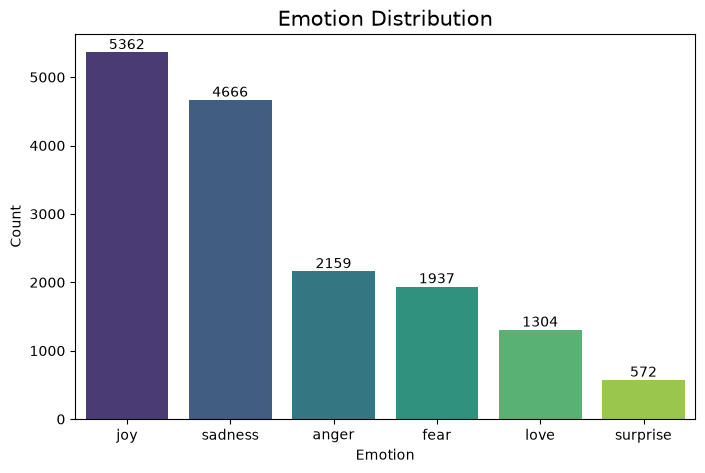

Joy and Sadness are the most frequent emotions.
Surprise has the fewest samples.
The dataset is slightly imbalanced, which may influence the model to favor majority classes.


In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="emotion",
    order=df["emotion"].value_counts().index,
    palette="viridis"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Emotion Distribution", fontsize=15)
plt.xlabel("Emotion")
plt.ylabel("Count")

plt.show()

print(f"Joy and Sadness are the most frequent emotions.")
print(f"Surprise has the fewest samples.")
print(f"The dataset is slightly imbalanced, which may influence the model to favor majority classes.")

In [108]:
df["text_length"] = df["text"].apply(len)

print(f"📏 Text Length Statistics : {df['text_length'].describe()}")

📏 Text Length Statistics : count    16000.000000
mean        96.845812
std         55.904953
min          7.000000
25%         53.000000
50%         86.000000
75%        129.000000
max        300.000000
Name: text_length, dtype: float64


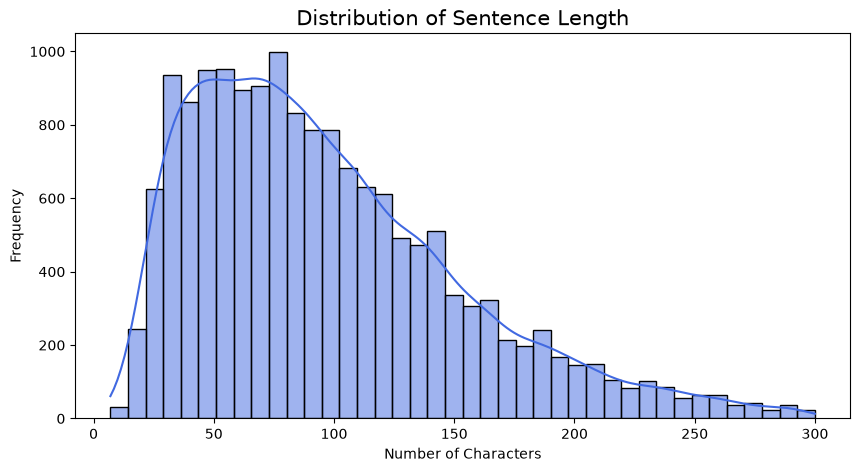

 Most sentences are relatively short.
Average sentence length is 97 characters.
The shortest sentence contains 7 characters.
The longest sentence contains 300 characters.
Most samples lie between 50–130 characters, making this dataset suitable for traditional NLP approaches such as TF-IDF.


In [109]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["text_length"],
    bins=40,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of Sentence Length", fontsize=15)
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()



print(f" Most sentences are relatively short.")
print(f"Average sentence length is 97 characters.")
print(f"The shortest sentence contains 7 characters.")
print(f"The longest sentence contains 300 characters.")
print(f"Most samples lie between 50–130 characters, making this dataset suitable for traditional NLP approaches such as TF-IDF.")

Now we'll clean and preprocess the text before converting it into numerical features for machine learning.

In [110]:
import re
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Stopwords
stop_words = set(stopwords.words("english"))

# Keep negation words because they change the meaning
negation_words = {
    "not",
    "no",
    "nor",
    "never",
    "don't",
    "doesn't",
    "didn't",
    "can't",
    "couldn't",
    "won't",
    "wouldn't",
    "isn't",
    "aren't",
    "wasn't",
    "weren't",
    "hasn't",
    "haven't",
    "hadn't",
}

stop_words = stop_words - negation_words

# Lemmatizer
lemmatizer = WordNetLemmatizer()

Instead of cleaning the text manually every time, we'll create a reusable function that performs all preprocessing steps automatically.

This function can later be reused during both training and prediction.

In [111]:
# Building a Text Preprocessing Function
NEGATIONS     = {"not", "no", "nor", "never"}
CLAUSE_BREAKS = {"but"}   # punctuation clause-breaks handled by the split below

def _process_clause(clause):
    """Clean + negation-scope-mark a single clause."""
    clause = clause.encode("ascii", "ignore").decode()
    clause = clause.translate(str.maketrans("", "", string.punctuation))
    tokens = word_tokenize(clause)
    tokens = [w for w in tokens if w not in stop_words]

    negate = False
    tagged = []
    for w in tokens:
        if w in CLAUSE_BREAKS:      # e.g. "but" resets negation
            negate = False
            continue
        if w in NEGATIONS:
            negate = True
            tagged.append(w)
            continue
        tagged.append(f"NEG_{w}" if negate else w)

    return [lemmatizer.lemmatize(w) for w in tagged]


def preprocess_text(text):
    """
    Cleans and preprocesses text for emotion classification.
    Splits on clause-break punctuation so negation scope resets per clause.
    """
    if not isinstance(text, str):
        return ""

    text = contractions.fix(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\d+", "", text)

    # Split into clauses on . , ; ! ? — negation does NOT cross these.
    clauses = re.split(r"[.,;!?]+", text)

    all_tokens = []
    for clause in clauses:
        if clause.strip():
            all_tokens.extend(_process_clause(clause))

    return " ".join(all_tokens)

Before applying preprocessing to the entire dataset, let's test it on a sample sentence to ensure each cleaning step works correctly.

In [112]:
sample = "I am soooo HAPPY!!! 😍😍 Visit https://google.com now!!!"

print("Original Text:")
print(sample)

print("\nCleaned Text:")
print(preprocess_text(sample))

Original Text:
I am soooo HAPPY!!! 😍😍 Visit https://google.com now!!!

Cleaned Text:
soooo happy visit


we'll apply it to every sentence in the dataset.

The cleaned text will be stored in a new column called **clean_text**, which will later be converted into numerical features using TF-IDF.

In [113]:
from tqdm import tqdm

tqdm.pandas()

df["clean_text"] = df["text"].progress_apply(preprocess_text)

100%|██████████| 16000/16000 [00:03<00:00, 4155.07it/s]


In [114]:
df[["text", "clean_text"]].head(10)

,text,clean_text
0,i didnt feel humiliated,not NEG_feel NEG_humiliated
1,i can go from feeling so hopeless to so damned...,go feeling hopeless damned hopeful around some...
2,im grabbing a minute to post i feel greedy wrong,grabbing minute post feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,ever feeling nostalgic fireplace know still pr...
4,i am feeling grouchy,feeling grouchy
5,ive been feeling a little burdened lately wasn...,feeling little burdened lately not NEG_sure
6,ive been taking or milligrams or times recomme...,taking milligram time recommended amount falle...
7,i feel as confused about life as a teenager or...,feel confused life teenager jaded year old man
8,i have been with petronas for years i feel tha...,petronas year feel petronas performed well mad...
9,i feel romantic too,feel romantic


In [115]:
df[["text", "clean_text"]].sample(5, random_state=42)

,text,clean_text
8756,ive made it through a week i just feel beaten ...,made week feel beaten
4660,i feel this strategy is worthwhile,feel strategy worthwhile
6095,i feel so worthless and weak what does he have...,feel worthless weak say want find
304,i feel clever nov,feel clever nov
8241,im moved in ive been feeling kind of gloomy,moved feeling kind gloomy


In [116]:
# ---------------------------------------------------------------
# Synthetic negation augmentation (curated lexicon version)
# ---------------------------------------------------------------
# The previous auto-discovered word list included junk tokens like
# "not", "would", "feel", "make", which polluted the training signal.
# Here we use a small hand-curated lexicon of unambiguous emotion
# adjectives, so every synthetic row carries a clear negated signal.
# ---------------------------------------------------------------

EMOTION_LEXICON = {
    "joy": [
        "happy", "glad", "cheerful", "delighted", "joyful", "excited",
        "content", "pleased", "thrilled", "elated", "ecstatic",
        "grateful", "optimistic", "hopeful",
    ],
    "sadness": [
        "sad", "unhappy", "depressed", "miserable", "gloomy", "sorrowful",
        "heartbroken", "lonely", "disappointed", "hopeless", "regretful",
        "melancholy", "downcast",
    ],
    "anger": [
        "angry", "furious", "mad", "irritated", "annoyed", "resentful",
        "outraged", "hostile", "bitter", "frustrated",
    ],
    "fear": [
        "afraid", "scared", "terrified", "anxious", "worried",
        "nervous", "frightened", "fearful", "panicked",
    ],
    "love": [
        "loving", "affectionate", "caring", "devoted", "fond",
        "tender", "warm", "attached",
    ],
    "surprise": [
        "surprised", "amazed", "astonished", "shocked", "stunned",
        "startled",
    ],
}

# Label-flip: what the sentence means once negated.
FLIP = {
    "joy":      "sadness",
    "sadness":  "joy",
    "anger":    "love",
    "love":     "anger",
    "fear":     "joy",       # "not afraid" ≈ relieved
    "surprise": "joy",       # "not surprised" ≈ neutral/content
}

# Keep templates minimal to avoid re-introducing filler tokens.
TEMPLATES = [
    "i am not {w}",
    "i do not feel {w}",
    "i never feel {w}",
    "i don't feel {w}",
]

synthetic_rows = []
for source_emo, words in EMOTION_LEXICON.items():
    target_emo = FLIP[source_emo]
    for w in words:
        for tpl in TEMPLATES:
            synthetic_rows.append({
                "text":    tpl.format(w=w),
                "emotion": target_emo,
            })

synthetic_df = pd.DataFrame(synthetic_rows)
synthetic_df["clean_text"]  = synthetic_df["text"].apply(preprocess_text)
synthetic_df["text_length"] = synthetic_df["text"].apply(len)

# Drop any synthetic row whose cleaned text is trivial (e.g. just "not")
synthetic_df = synthetic_df[
    synthetic_df["clean_text"].str.contains(r"NEG_", regex=True)
].reset_index(drop=True)

print(f"Generated {len(synthetic_df)} clean synthetic negated examples.")
print(synthetic_df["emotion"].value_counts())
print(synthetic_df.sample(10, random_state=0).to_string())

df = pd.concat([df, synthetic_df], ignore_index=True)
print("\nNew dataset shape:", df.shape)

Generated 240 clean synthetic negated examples.
emotion
joy        112
sadness     56
love        40
anger       32
Name: count, dtype: int64
                        text  emotion                   clean_text  text_length
109      i do not feel angry     love       not NEG_feel NEG_angry           19
71    i don't feel miserable      joy   not NEG_feel NEG_miserable           22
37      i do not feel elated  sadness      not NEG_feel NEG_elated           20
74       i never feel gloomy      joy    never NEG_feel NEG_gloomy           19
108           i am not angry     love                not NEG_angry           14
227  i don't feel astonished      joy  not NEG_feel NEG_astonished           23
156       i am not terrified      joy            not NEG_terrified           18
220          i am not amazed      joy               not NEG_amazed           15
152          i am not scared      joy               not NEG_scared           15
194      i never feel caring    anger    never NEG_feel NE

### Feature Engineering using TF-IDF

Now, we'll use **TF-IDF (Term Frequency - Inverse Document Frequency)** to informative words while reducing the weight of commonly occurring words.

In [117]:
X = df["clean_text"]
y = df["emotion"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [118]:
print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

Training Samples : (12992,)
Testing Samples  : (3248,)


In [119]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training Matrix :", X_train_tfidf.shape)
print("Testing Matrix  :", X_test_tfidf.shape)



Training Matrix : (12992, 5000)
Testing Matrix  : (3248, 5000)


### Model Training and Evaluation

Instead of relying on a single algorithm, we'll compare multiple classifiers (Multinomial Naive Bayes, Logistic Regression, Support Vector Machine) and evaluate their performance.
And then, we'll select the model with the highest performance for deployment.

In [120]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

models = {
    "Naive Bayes": MultinomialNB(),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Linear SVM": CalibratedClassifierCV(
        estimator=LinearSVC(random_state=42),
        cv=5
    )
}

In [121]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train_tfidf, y_train)

    predictions = model.predict(X_test_tfidf)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, average="weighted"),
        "Recall": recall_score(y_test, predictions, average="weighted"),
        "F1 Score": f1_score(y_test, predictions, average="weighted")
    })
    
results_df = (
    pd.DataFrame(results)
      .sort_values(by="Accuracy", ascending=False)
      .reset_index(drop=True)
)

results_df

Training Naive Bayes...
Training Logistic Regression...
Training Linear SVM...


,Model,Accuracy,Precision,Recall,F1 Score
0,Linear SVM,0.861761,0.860775,0.861761,0.860740
1,Logistic Regression,0.829433,0.833595,0.829433,0.823074
2,Naive Bayes,0.759236,0.798994,0.759236,0.734613


### Model Evaluation
To better understand the model's performance and evaluate the model for each emotion individually, we'll generate Classification Report and Confusion Matrix

In [122]:
best_model = models["Linear SVM"]

predictions = best_model.predict(X_test_tfidf)
print(classification_report(y_test, predictions))
cm = confusion_matrix(y_test, predictions)

              precision    recall  f1-score   support

       anger       0.87      0.85      0.86       438
        fear       0.84      0.83      0.83       388
         joy       0.86      0.91      0.89      1095
        love       0.78      0.73      0.76       269
     sadness       0.89      0.89      0.89       944
    surprise       0.78      0.64      0.71       114

    accuracy                           0.86      3248
   macro avg       0.84      0.81      0.82      3248
weighted avg       0.86      0.86      0.86      3248



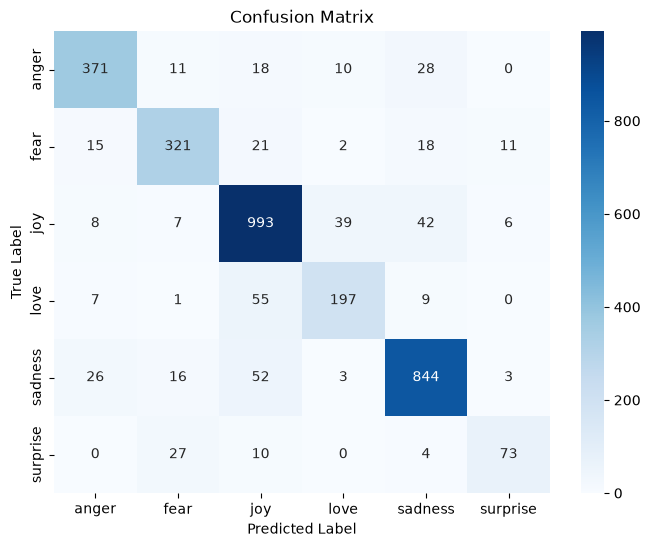

In [123]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_model.classes_,
    yticklabels=best_model.classes_
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.show()

In [124]:
# Artifact serialization moved to the end of the notebook,
# after GridSearchCV has produced `best_pipeline`.
# The three-file contract (emotion_model.pkl, tfidf_vectorizer.pkl,
# label_classes.pkl) is preserved there.
print("V1 evaluation complete. Artifacts will be written after V2 tuning.")

V1 evaluation complete. Artifacts will be written after V2 tuning.


In [125]:
test_sentences = [
    "I am happy.",
    "I am not happy.",
    "I don't like this movie.",
    "I never wanted this.",
    "I can't believe this happened.",
    "I am not excited anymore."
]

for sentence in test_sentences:
    cleaned = preprocess_text(sentence)
    vector = tfidf.transform([cleaned])

    prediction = best_model.predict(vector)[0]

    print("=" * 60)
    print("Original   :", sentence)
    print("Processed  :", cleaned)
    print("Prediction :", prediction)

Original   : I am happy.
Processed  : happy
Prediction : joy
Original   : I am not happy.
Processed  : not NEG_happy
Prediction : sadness
Original   : I don't like this movie.
Processed  : not NEG_like NEG_movie
Prediction : sadness
Original   : I never wanted this.
Processed  : never NEG_wanted
Prediction : joy
Original   : I can't believe this happened.
Processed  : not NEG_believe NEG_happened
Prediction : joy
Original   : I am not excited anymore.
Processed  : not NEG_excited NEG_anymore
Prediction : sadness


### Version 2.1 - Pipeline + Hyperparameter Tuning

In [126]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC

pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=5000,
            ngram_range=(1, 2)
        )
    ),
    (
        "classifier",
        CalibratedClassifierCV(
            estimator=LinearSVC(
                random_state=42,
                class_weight="balanced"
            ),
            cv=5
        )
    )
])

print(pipeline)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
                ('classifier',
                 CalibratedClassifierCV(cv=5,
                                        estimator=LinearSVC(class_weight='balanced',
                                                            random_state=42)))])


In [127]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "tfidf__min_df": [2, 5],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "classifier__estimator__C": [0.5, 1, 2]
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=2
)

print("Total combinations:",
      len(param_grid["tfidf__min_df"])
      * len(param_grid["tfidf__ngram_range"])
      * len(param_grid["classifier__estimator__C"]))

Total combinations: 12


In [128]:
grid.fit(X_train, y_train)

best_pipeline = grid.best_estimator_

print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV Macro F1:")
print(round(grid.best_score_, 4))

Fitting 5 folds for each of 12 candidates, totalling 60 fits


Best Parameters:
{'classifier__estimator__C': 0.5, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}

Best CV Macro F1:
0.8181


In [129]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = best_pipeline.predict(X_test)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}\n")

print(classification_report(y_test, y_pred))

print("\nBest Parameters:")
print(grid.best_params_)

Accuracy : 0.8642

              precision    recall  f1-score   support

       anger       0.87      0.85      0.86       438
        fear       0.84      0.84      0.84       388
         joy       0.87      0.89      0.88      1095
        love       0.78      0.77      0.78       269
     sadness       0.89      0.90      0.89       944
    surprise       0.78      0.67      0.72       114

    accuracy                           0.86      3248
   macro avg       0.84      0.82      0.83      3248
weighted avg       0.86      0.86      0.86      3248


Best Parameters:
{'classifier__estimator__C': 0.5, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}


In [130]:
test_sentences = [
    "i am happy",
    "i am not happy",
    "i am sad",
    "i am not sad",
    "i am excited",
    "i am not excited",
]

for sentence in test_sentences:
    cleaned = preprocess_text(sentence)   # match training distribution
    prediction    = best_pipeline.predict([cleaned])[0]
    probabilities = best_pipeline.predict_proba([cleaned])[0]
    confidence    = probabilities.max()

    print(
        f"{sentence:<22} -> "
        f"{prediction:<10} "
        f"({confidence:.4f})   [cleaned='{cleaned}']"
    )

i am happy             -> joy        (0.9525)   [cleaned='happy']
i am not happy         -> sadness    (0.6149)   [cleaned='not NEG_happy']
i am sad               -> sadness    (0.9565)   [cleaned='sad']
i am not sad           -> joy        (0.7953)   [cleaned='not NEG_sad']
i am excited           -> joy        (0.9211)   [cleaned='excited']
i am not excited       -> sadness    (0.5895)   [cleaned='not NEG_excited']


In [ ]:
import joblib
from pathlib import Path

MODELS_DIR = Path("../ai-service/models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Extract the fitted components from the tuned pipeline.
fitted_tfidf      = best_pipeline.named_steps["tfidf"]
fitted_classifier = best_pipeline.named_steps["classifier"]

# Sanity checks: tuned params survived and classifier is fitted.
assert fitted_tfidf.ngram_range == (1, 2), \
    f"Expected ngram_range=(1,2), got {fitted_tfidf.ngram_range}"
assert fitted_tfidf.min_df == 2, \
    f"Expected min_df=2, got {fitted_tfidf.min_df}"
assert hasattr(fitted_classifier, "classes_"), "Classifier is not fitted."

joblib.dump(fitted_classifier,          MODELS_DIR / "emotion_model.pkl")
joblib.dump(fitted_tfidf,               MODELS_DIR / "tfidf_vectorizer.pkl")
joblib.dump(fitted_classifier.classes_, MODELS_DIR / "label_classes.pkl")

print("Saved three artifacts compatible with the FastAPI service:")
print(" -", MODELS_DIR / "emotion_model.pkl")
print(" -", MODELS_DIR / "tfidf_vectorizer.pkl")
print(" -", MODELS_DIR / "label_classes.pkl")

Saved three artifacts compatible with the FastAPI service:
 - ..\models\emotion_model.pkl
 - ..\models\tfidf_vectorizer.pkl
 - ..\models\label_classes.pkl
